# mapgen — v13 (canonical)

The only kept version. **v13 = 2 gangen per domein op de naar-binnen zijden
(richting 't midden), 7 domeinen, gevulde rand, isolatie-getoetst.**
Earlier proof-of-concept versions (v1–v12) were dropped — v13 worked best.

**Run all cells top-to-bottom from this folder (`map/`).** Output:
- `background.png` — the navigation layer the ABM app extracts its walkable grid from


In [1]:
# v13-generator: 2 gangen per domein op naar-binnen zijden
import heapq, random
W13,H13=110,70
WALL,FLOOR,CORR,COUCH=0,1,2,3; WALK13={FLOOR,CORR}
DOM7=["gezondheid","kennis","techniek","geld","relaties","richting","creativiteit"]

def _fill(g,rx,ry,rw,rh,t):
    for y in range(ry,ry+rh):
        for x in range(rx,rx+rw):
            if 0<=x<W13 and 0<=y<H13: g[y][x]=t
def _free(g,rx,ry,rw,rh,pad):
    if rw<6 or rh<6: return False
    for y in range(ry-pad,ry+rh+pad):
        for x in range(rx-pad,rx+rw+pad):
            if not(0<=x<W13 and 0<=y<H13): return False
            if g[y][x]!=WALL: return False
    return True
def _c(r): rx,ry,rw,rh=r; return (rx+rw//2, ry+rh//2)
def _line(g,x1,y1,x2,y2):
    if x1==x2:
        for y in range(min(y1,y2),max(y1,y2)+1):
            if g[y][x1]==WALL: g[y][x1]=CORR
    else:
        for x in range(min(x1,x2),max(x1,x2)+1):
            if g[y1][x]==WALL: g[y1][x]=CORR

def _tap(g,a,maxbend):                 # 1 anker -> dichtstbijzijnde gang, max bochten; carve
    st0=(a,(0,0),0)
    if not(0<=a[0]<W13 and 0<=a[1]<H13) or g[a[1]][a[0]] not in (WALL,CORR): return False
    oq=[(0,st0)]; came={st0:None}; g0={st0:0}
    while oq:
        cost,st=heapq.heappop(oq); (cx,cy),pd,bends=st
        if g[cy][cx]==CORR and pd!=(0,0):
            cur=st
            while cur is not None:
                x,y=cur[0]
                if g[y][x]==WALL: g[y][x]=CORR
                cur=came[cur]
            return True
        for dx,dy in ((1,0),(-1,0),(0,1),(0,-1)):
            nx,ny=cx+dx,cy+dy
            if not(0<=nx<W13 and 0<=ny<H13) or g[ny][nx] not in (WALL,CORR): continue
            nd=(dx,dy); nb=bends+(1 if pd!=(0,0) and nd!=pd else 0)
            if nb>maxbend: continue
            ns=((nx,ny),nd,nb); ng=cost+(0.3 if g[ny][nx]==CORR else 1.0)
            if ns not in g0 or ng<g0[ns]:
                g0[ns]=ng; came[ns]=st; heapq.heappush(oq,(ng,ns))
    return False

def v13_generate(seed):
    rng=random.Random(seed)
    g=[[WALL]*W13 for _ in range(H13)]
    cxm,cym=W13//2,H13//2
    cw,chh=36,24; cx0=cxm-cw//2; cy0=cym-chh//2
    _fill(g,cx0,cy0,cw,chh,FLOOR)
    rooms=[{"room":(cx0,cy0,cw,chh),"topic":DOM7[0]}]
    ux,uy=cx0+cw//2,cy0+chh//2
    Rt,Rb=cy0-4,cy0+chh+3; Cl,Cr=cx0-5,cx0+cw+4
    # midden: gangen uit ALLE zijden (frame + stub per zijde, mag splitsen)
    _line(g,Cl,Rt,Cr,Rt); _line(g,Cl,Rb,Cr,Rb); _line(g,Cl,Rt,Cl,Rb); _line(g,Cr,Rt,Cr,Rb)
    _line(g,ux,cy0-1,ux,Rt); _line(g,ux,cy0+chh,ux,Rb); _line(g,cx0-1,uy,Cl,uy); _line(g,cx0+cw,uy,Cr,uy)
    # rand-domeinen tegelen (zelfde slots als v12)
    def jit(): return rng.randint(0,3)
    def box(x0,y0,x1,y1):
        bw=(x1-x0)-jit(); bh=(y1-y0)-jit(); return (x0,y0,max(7,bw),max(7,bh))
    M=1
    slots=[box(M,M,ux-1,Rt-1),box(ux+2,M,W13-M,Rt-1),box(M,Rb+2,ux-1,H13-M),
           box(ux+2,Rb+2,W13-M,H13-M),box(M,Rt+1,Cl-1,Rb),box(Cr+2,Rt+1,W13-M,Rb)]
    for si,(rx,ry,bw,bh) in enumerate(slots):
        if not _free(g,rx,ry,bw,bh,1): return None
        _fill(g,rx,ry,bw,bh,FLOOR)
        rooms.append({"room":(rx,ry,bw,bh),"topic":DOM7[1+si]})
    # per rand-domein: 2 gangen op de NAAR-BINNEN zijden, deur op de helft richting't midden
    def clamp(v,lo,hi): return max(lo,min(v,hi))
    for n in rooms[1:]:
        rx,ry,rw,rh=n["room"]
        outL=rx<=2; outR=rx+rw>=W13-3; outT=ry<=2; outB=ry+rh>=H13-3
        # ankers per zijde, gepositioneerd richting't midden (inner half)
        sides={}
        if not outT: sides["N"]=(clamp(cxm,rx+1,rx+rw-2),ry-1)
        if not outB: sides["S"]=(clamp(cxm,rx+1,rx+rw-2),ry+rh)
        if not outL: sides["W"]=(rx-1,clamp(cym,ry+1,ry+rh-2))
        if not outR: sides["E"]=(rx+rw,clamp(cym,ry+1,ry+rh-2))
        # voorkeur: zijde die't meest naar't midden wijst eerst
        def towards(s):
            a=sides[s]; return (a[0]-cxm)**2+(a[1]-cym)**2
        order=sorted(sides,key=towards)
        made=0
        for s in order:
            if made>=2: break
            if _tap(g,sides[s],3): made+=1
        if made<2: return None
    return {"grid":g,"rooms":rooms}

def v13_astar(g,s,goal):
    if s==goal: return True
    seen={s}; oq=[(0,s)]
    while oq:
        _,c=heapq.heappop(oq); cx,cy=c
        if c==goal: return True
        for dx,dy in ((1,0),(-1,0),(0,1),(0,-1)):
            nx,ny=cx+dx,cy+dy
            if 0<=nx<W13 and 0<=ny<H13 and g[ny][nx] in WALK13 and (nx,ny) not in seen:
                seen.add((nx,ny)); heapq.heappush(oq,(abs(nx-goal[0])+abs(ny-goal[1]),(nx,ny)))
    return False

def v13_validate(m):
    g=m["grid"]; rooms=m["rooms"]; errs=[]; n=len(rooms)
    for i in range(n):
        for j in range(n):
            if i==j: continue
            g2=[row[:] for row in g]
            for k,o in enumerate(rooms):
                if k in (i,j): continue
                ox,oy,ow,oh=o["room"]
                for y in range(oy,oy+oh):
                    for x in range(ox,ox+ow): g2[y][x]=WALL
            if not v13_astar(g2,_c(rooms[i]["room"]),_c(rooms[j]["room"])):
                errs.append("%s->%s FAALT"%(rooms[i]["topic"],rooms[j]["topic"])); break
        if errs: break
    return errs

m13=None
for s in range(400):
    cand=v13_generate(s)
    if cand and not v13_validate(cand): m13=cand; CANON13=s; break
print("canon seed:",CANON13 if m13 else None,"|",("GEEN — 2 gangen/domein naar-binnen, isolatie ok" if (m13 and not v13_validate(m13)) else "FAIL"))

canon seed: 0 | GEEN — 2 gangen/domein naar-binnen, isolatie ok


wrote background.png  seed 0 grid 110 x 70


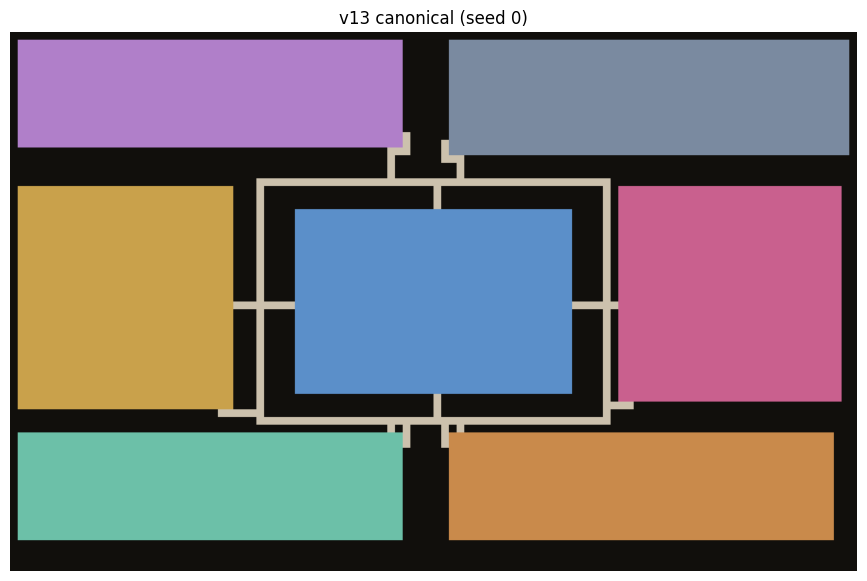

In [2]:
# v13 EXPORT -> background.png, the map the ABM app reads.
# Run the notebook from the map/ folder (where it lives).
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# topic -> (app domain id, RGB). Colors are EXACTLY the app's palette so its
# pixel classifier maps each area back to the right domain id.
APP = {"gezondheid":(4,(91,143,201)),  "kennis":(1,(176,127,201)),
       "techniek":(2,(122,138,160)),   "geld":(6,(108,192,168)),
       "relaties":(7,(201,138,75)),    "richting":(3,(201,161,75)),
       "creativiteit":(5,(201,96,142))}
CORRIDOR_RGB=(204,193,173); VOID_RGB=(17,15,12); SCALE=16

m = v13_generate(CANON13)
assert m and not v13_validate(m), "v13 canon map invalid"
g = m["grid"]

# per cell: -1 wall, 0 corridor, app domain id on room floors
idg=[[-1 if g[y][x]==WALL else 0 for x in range(W13)] for y in range(H13)]
for n in m["rooms"]:
    rx,ry,rw,rh=n["room"]; did=APP[n["topic"]][0]
    for y in range(ry,ry+rh):
        for x in range(rx,rx+rw):
            if g[y][x]==FLOOR: idg[y][x]=did
colormap={0:CORRIDOR_RGB}
for t,(i,c) in APP.items(): colormap[i]=c

# background.png (no title, no border: just the map)
img=np.zeros((H13*SCALE,W13*SCALE,3),np.uint8)
for y in range(H13):
    for x in range(W13):
        v=idg[y][x]; img[y*SCALE:(y+1)*SCALE, x*SCALE:(x+1)*SCALE]=VOID_RGB if v<0 else colormap[v]
Image.fromarray(img).save("background.png")

print("wrote background.png  seed",CANON13,"grid",W13,"x",H13)
plt.figure(figsize=(11,7)); plt.imshow(img); plt.title("v13 canonical (seed %d)"%CANON13); plt.axis("off"); plt.show()
